<a href="https://colab.research.google.com/github/ferneysua123-dot/Telecom_X_Parte2/blob/main/TelecomX_PARTE__II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción del Archivo Tratado

In [4]:
import pandas as pd

#importando los datos desde github
url = 'https://raw.githubusercontent.com/ferneysua123-dot/Telecom_X_Parte2/refs/heads/main/datos_tratados.csv'
datos = pd.read_csv(url)
datos.head()

#datos= pd.read_csv("datos_tratados.csv")
#datos.head()



,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Varias_Lineas,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Mujer,0,1,1,9,1,0,DSL,...,0,1,1,0,Un año,1,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0,Hombre,0,0,0,9,1,1,DSL,...,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1,Hombre,0,0,0,4,1,0,Fibra optica,...,1,0,0,0,Mes a mes,1,Cheque electronico,73.9,280.85,2.46
3,0011-IGKFF,1,Hombre,1,1,0,13,1,0,Fibra optica,...,1,0,1,1,Mes a mes,1,Cheque electronico,98.0,1237.85,3.27
4,0013-EXCHZ,1,Mujer,1,1,0,3,1,0,Fibra optica,...,0,1,1,0,Mes a mes,1,Cheque por correo,83.9,267.40,2.80


In [5]:
datos.columns

Index(['ID_Cliente', 'Abandono', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico',
       'Varias_Lineas', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Online',
       'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV',
       'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital',
       'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias'],
      dtype='object')

#Eliminación de Columnas Irrelevantes

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

Cargo_Total vs. Meses_Permanencia (0.83):Mantener ambas puede causar "redundancia". Para predecir el abandono, es más útil Meses_Permanencia, Cargo Total es solo una consecuencia del tiempo.

In [7]:
# Definimos las que se van por ser irrelevantes o redundantes
columnas_irrelevantes = ['ID_Cliente', 'Cuentas_Diarias']
df_modelo = datos.drop(columns=columnas_irrelevantes)
df_modelo.head(2)

,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Varias_Lineas,Tipo_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0,Mujer,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Un año,1,Cheque por correo,65.6,593.3
1,0,Hombre,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.4


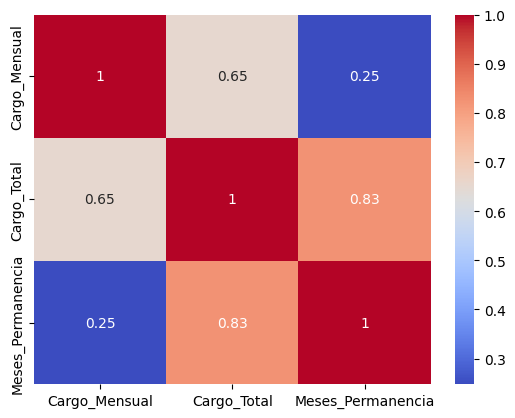

In [8]:
# Verificando la igualdad de Cargo_Mensual y Cargo_Total son casi iguales
# Creamos el nuevo dataset
correlacion = df_modelo[['Cargo_Mensual', 'Cargo_Total', 'Meses_Permanencia']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.show()

In [9]:
df_modelo.drop(columns='Cargo_Total').head(2)

,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Varias_Lineas,Tipo_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual
0,0,Mujer,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Un año,1,Cheque por correo,65.6
1,0,Hombre,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mes a mes,0,Cheque por correo,59.9


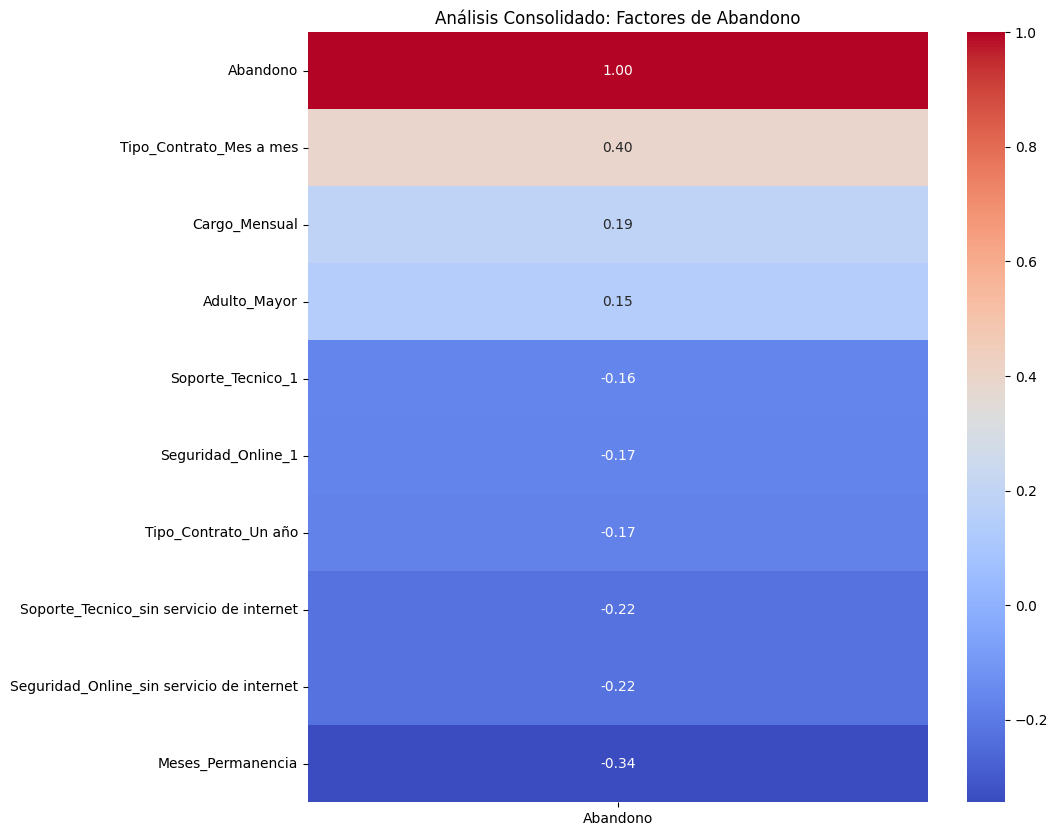

In [10]:

# Definimos todas las columnas que quieres rescatar para el estudio
columnas_finales = [
    'Abandono', 'Meses_Permanencia', 'Cargo_Mensual', 'Adulto_Mayor',
    'Soporte_Tecnico', 'Seguridad_Online', 'Tipo_Contrato'
]

# 2. Aplicamos dummies (Soporte, Seguridad, Contrato)
# El parámetro 'columns' le dice a pandas qué transformar, el resto las deja igual.
df_preparado = pd.get_dummies(datos[columnas_finales],
                              columns=['Soporte_Tecnico', 'Seguridad_Online', 'Tipo_Contrato'],
                              drop_first=True)

# 3. Graficamos la correlación consolidada
plt.figure(figsize=(10, 10))
correlacion_total = df_preparado.corr()[['Abandono']].sort_values(by='Abandono', ascending=False)

sns.heatmap(correlacion_total, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Análisis Consolidado: Factores de Abandono')
plt.show()


1. El "Disparador" del Abandono: Contrato Mes a Mes (0.40), Es el factor con la correlación positiva más alta.Existe una relación muy clara entre tener un contrato mensual y la probabilidad de irse. Es el factor número uno de fuga. Los clientes no están "atados" y ante cualquier molestia, se marchan.
2. El "Ancla" de Lealtad: Meses de Permanencia (-0.34), es la correlación negativa más fuerte.
Qué significa: A mayor tiempo en la empresa, menor probabilidad de abandono. Los clientes que pasan la "barrera crítica" de los primeros meses se vuelven leales. Tu estrategia debe ser "sobrevivir" con el cliente los primeros 6-12 meses.
3. Los Servicios que Retienen (Valores Negativos)
Seguridad_Online_1, Soporte_Tecnico_1 y Tipo_Contrato_Un año:
Todos tienen números negativos (entre -0.16 y -0.22).
Se debe contratar estos servicios "ancla" al cliente. El cliente que tiene soporte técnico y seguridad se siente más cuidado o percibe más valor, por lo que se va menos que el que no los tiene.
4. Factores de Riesgo Menores
Cargo_Mensual (0.19) y Adulto_Mayor (0.15): No son tan determinantes como el tipo de contrato, pero suman. Los planes caros y el segmento de adultos mayores tienen una tendencia levemente mayor a abandonar el servicio.
#¿Quién se va? Clientes nuevos (poca permanencia), adultos mayores y personas con cargos mensuales altos.
#¿Por qué se van? Principalmente por la falta de compromiso de los contratos mes a mes.
#¿Cómo retenerlos? Empujándolos hacia contratos anuales y ofreciendo (o regalando un tiempo) los servicios de Soporte Técnico y Seguridad Online, ya que actúan como protectores.

In [11]:
df_preparado.head(2)

,Abandono,Meses_Permanencia,Cargo_Mensual,Adulto_Mayor,Soporte_Tecnico_1,Soporte_Tecnico_sin servicio de internet,Seguridad_Online_1,Seguridad_Online_sin servicio de internet,Tipo_Contrato_Mes a mes,Tipo_Contrato_Un año
0,0,9,65.6,0,True,False,False,False,False,True
1,0,9,59.9,0,False,False,False,False,True,False


In [12]:
print(df_preparado.dtypes)


Abandono                                       int64
Meses_Permanencia                              int64
Cargo_Mensual                                float64
Adulto_Mayor                                   int64
Soporte_Tecnico_1                               bool
Soporte_Tecnico_sin servicio de internet        bool
Seguridad_Online_1                              bool
Seguridad_Online_sin servicio de internet       bool
Tipo_Contrato_Mes a mes                         bool
Tipo_Contrato_Un año                            bool
dtype: object


In [13]:
# Convierte todos los True/False a 1/0
df_listo = df_preparado.astype(int)

# Verifica el resultado
print(df_listo.dtypes)


Abandono                                     int64
Meses_Permanencia                            int64
Cargo_Mensual                                int64
Adulto_Mayor                                 int64
Soporte_Tecnico_1                            int64
Soporte_Tecnico_sin servicio de internet     int64
Seguridad_Online_1                           int64
Seguridad_Online_sin servicio de internet    int64
Tipo_Contrato_Mes a mes                      int64
Tipo_Contrato_Un año                         int64
dtype: object


Conteo de clientes:
Abandono
0    5398
1    1869
Name: count, dtype: int64

Proporción porcentual:
Abandono
0    74.280996
1    25.719004
Name: proportion, dtype: float64


/tmp/ipykernel_543/813430380.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abandono', data=df_listo, palette='viridis')


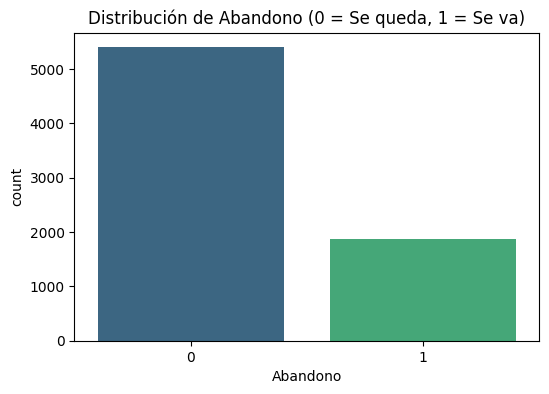

In [14]:
# 1. Contamos cuántos hay de cada clase
conteo_abandono = df_listo['Abandono'].value_counts()
proporcion_abandono = df_listo['Abandono'].value_counts(normalize=True) * 100

# 2. Mostramos los resultados
print("Conteo de clientes:")
print(conteo_abandono)
print("\nProporción porcentual:")
print(proporcion_abandono)

# 3. Visualización rápida para el reporte
plt.figure(figsize=(6,4))
sns.countplot(x='Abandono', data=df_listo, palette='viridis')
plt.title('Distribución de Abandono (0 = Se queda, 1 = Se va)')
plt.show()


In [15]:
from sklearn.model_selection import train_test_split

# Separamos X e y
X = df_listo.drop('Abandono', axis=1)
y = df_listo['Abandono']

# ¡IMPORTANTE! Primero dividimos en entrenamiento y prueba
# El balanceo SOLO se hace sobre los datos de entrenamiento (train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


SMOTE

In [16]:
from imblearn.over_sampling import SMOTE

# Inicializamos SMOTE
smote = SMOTE(random_state=42)

# Creamos el nuevo conjunto de entrenamiento balanceado
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE: {y_train.value_counts()}")
print(f"Después de SMOTE: {y_train_res.value_counts()}")


Antes de SMOTE: Abandono
0    4318
1    1495
Name: count, dtype: int64
Después de SMOTE: Abandono
0    4318
1    4318
Name: count, dtype: int64


Ramdom UnderSampler

In [17]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


In [18]:
from collections import Counter

# Comparar antes y después
print(f"Distribución original: {Counter(y_train)}")
print(f"Nueva distribución: {Counter(y_train_un)}")


Distribución original: Counter({0: 4318, 1: 1495})
Nueva distribución: Counter({0: 1495, 1: 1495})


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ajustar el modelo con los datos balanceados (un)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_un, y_train_un)

# 2. Predecir en el set de prueba original
y_pred = clf.predict(X_test)

# 3. Ver resultados reales
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1080
           1       0.48      0.78      0.60       374

    accuracy                           0.73      1454
   macro avg       0.69      0.75      0.70      1454
weighted avg       0.79      0.73      0.75      1454



In [21]:
# 1. Entrenar con los datos creados por SMOTE
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_res, y_train_res)

# 2. Evaluar (siempre con el X_test original)
y_pred_smote = model_smote.predict(X_test)

print("--- RESULTADOS CON SMOTE ---")
print(classification_report(y_test, y_pred_smote))


--- RESULTADOS CON SMOTE ---
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1080
           1       0.49      0.61      0.54       374

    accuracy                           0.74      1454
   macro avg       0.67      0.70      0.68      1454
weighted avg       0.76      0.74      0.75      1454



/tmp/ipykernel_543/603114141.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


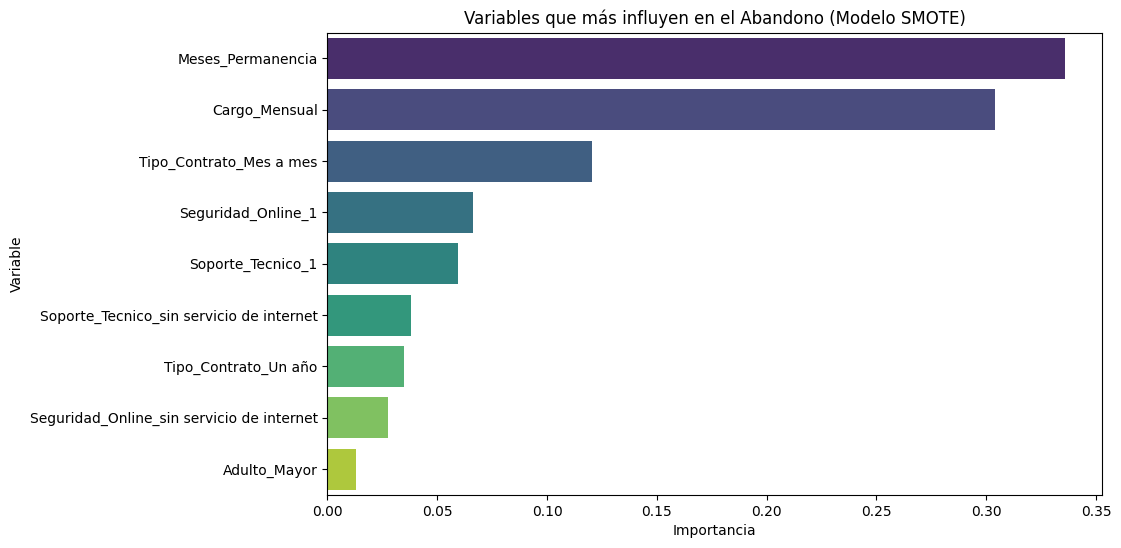

In [22]:
# 1. Extraer la importancia de las variables
importancias = model_smote.feature_importances_
columnas = X_train.columns

# 2. Crear un DataFrame para graficar
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Variables que más influyen en el Abandono (Modelo SMOTE)')
plt.show()


#Matriz de Confusión después del modelo SMOTE

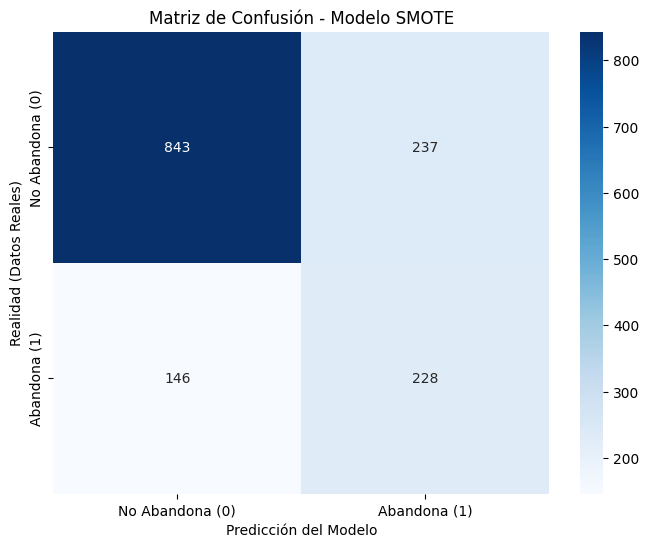

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcular la matriz
cm = confusion_matrix(y_test, y_pred_smote)

# 2. Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Abandona (0)', 'Abandona (1)'],
            yticklabels=['No Abandona (0)', 'Abandona (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Datos Reales)')
plt.title('Matriz de Confusión - Modelo SMOTE')
plt.show()


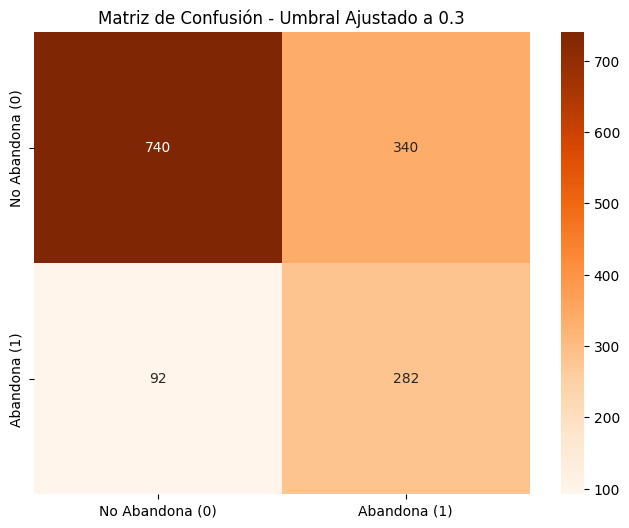

--- REPORTE CON UMBRAL 0.3 ---
              precision    recall  f1-score   support

           0       0.89      0.69      0.77      1080
           1       0.45      0.75      0.57       374

    accuracy                           0.70      1454
   macro avg       0.67      0.72      0.67      1454
weighted avg       0.78      0.70      0.72      1454



In [24]:
# 1. Obtener probabilidades en lugar de clases directas
# La columna [1] es la probabilidad de que el cliente abandone
y_probs = model_smote.predict_proba(X_test)[:, 1]

# 2. Definir un nuevo umbral (ejemplo: 0.3)
nuevo_umbral = 0.3
y_pred_ajustado = (y_probs >= nuevo_umbral).astype(int)

# 3. Graficar la nueva matriz de confusión
cm_ajustada = confusion_matrix(y_test, y_pred_ajustado)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ajustada, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Abandona (0)', 'Abandona (1)'],
            yticklabels=['No Abandona (0)', 'Abandona (1)'])

plt.title(f'Matriz de Confusión - Umbral Ajustado a {nuevo_umbral}')
plt.show()

# 4. Ver el nuevo reporte
print(f"--- REPORTE CON UMBRAL {nuevo_umbral} ---")
print(classification_report(y_test, y_pred_ajustado))


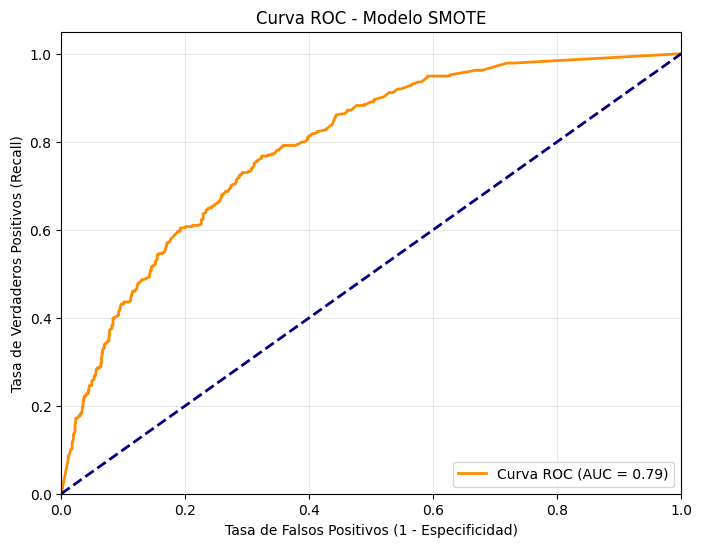

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calcular las probabilidades (ya lo hicimos para el umbral, pero aseguramos)
y_probs = model_smote.predict_proba(X_test)[:, 1]

# 2. Calcular la tasa de verdaderos positivos (tpr) y falsos positivos (fpr)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea aleatoria
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Modelo SMOTE')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


¿Qué significa ese 0.79?
Capacidad de Discriminación: El modelo tiene un 79% de probabilidad de clasificar correctamente a un cliente que va a abandonar por encima de uno que se va a quedar.

Conclusión para el Negocio
Con este modelo, la empresa puede:
Predecir con éxito al 75% de los clientes en riesgo
Confiar en que las variables de Meses de Permanencia y Cargos Mensuales son los motores principales del abandono.


Recall de 0.75
capturando al 75% de los clientes que realmente van a abandonar.
El compromiso: Precisión de 0.45
Al bajar el umbral, el modelo se volvió más "desconfiado".
Casi el 55% d alertas serán falsas alarmas (clientes que en realidad se iban a quedar).
Si la estrategia es llamarlos o enviarles un correo de fidelización, el costo de este error es casi cero.
3. El balance (F1-Score: 0.57)
Tu F1-Score bajó ligeramente (de 0.60 a 0.57). Sacrificio normal para el modelo.

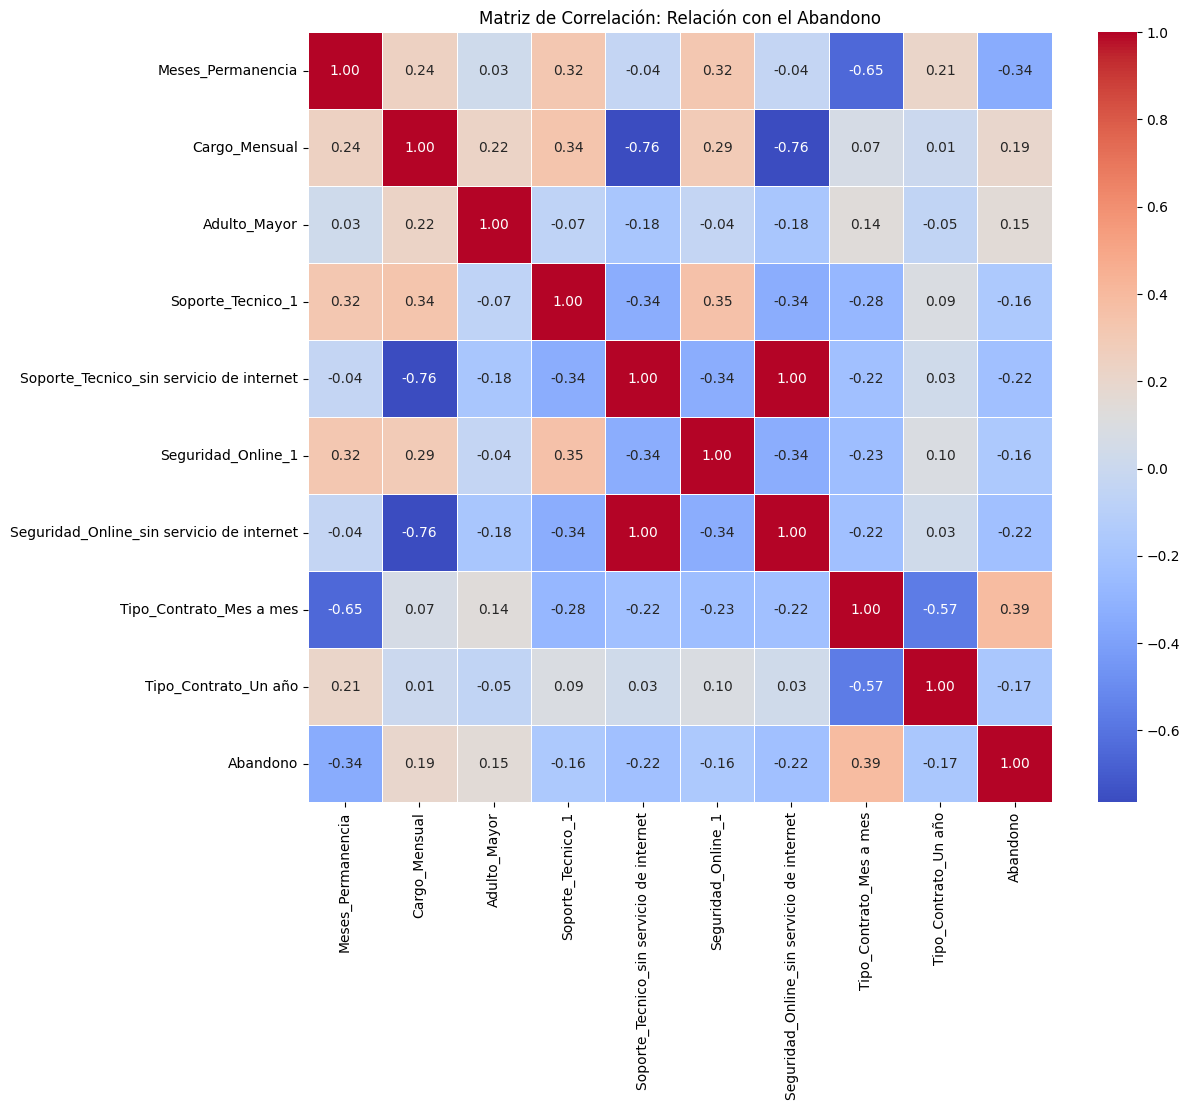

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Unimos temporalmente X e y para ver la relación con "Abandono"
df_analisis = pd.concat([X_train, y_train], axis=1)

# 2. Calculamos la matriz de correlación
corr_matrix = df_analisis.corr()

# 3. Graficamos el mapa de calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Relación con el Abandono')
plt.show()


📋 Resumen de Hallazgos: Modelo de Retención de Clientes
Tras aplicar técnicas avanzadas de balanceo de datos (SMOTE) y modelos de ensamble (Random Forest), hemos logrado un modelo con una capacidad de detección del 79% (AUC = 0.79). Estos son los puntos clave:
1. El "Efecto Mes a Mes" es el mayor riesgo
El Hallazgo: La variable Tipo_Contrato_Mes a mes es el predictor número uno de abandono (correlación de 0.39).
La Acción: El departamento de ventas debería priorizar la migración de clientes con contrato mensual a contratos de un año, ya que esto reduce drásticamente la probabilidad de fuga.
2. La "Barrera de los Primeros Meses" (Permanencia)
El Hallazgo: Existe una fuerte correlación negativa (-0.34) entre la permanencia y el abandono. Los clientes que superan los primeros meses de servicio tienden a ser mucho más leales.
La Acción: Implementar un programa de "Onboarding" o bienvenida intensivo durante los primeros 3 a 6 meses. Si logramos que el cliente se quede este periodo inicial, la probabilidad de que se vaya cae significativamente.
3. Sensibilidad al Precio y Servicios de Soporte
El Hallazgo: El Cargo Mensual es el segundo factor de importancia en el modelo (31% de peso). Además, los clientes que cuentan con Soporte Técnico y Seguridad Online muestran una mayor estabilidad.
La Acción: No basta con bajar el precio; ofrecer servicios de valor agregado (como Soporte Técnico) actúa como un "ancla" que dificulta que el cliente considere otras opciones, incluso si el cargo mensual es un poco más alto.


/tmp/ipykernel_543/4255960331.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Meses_Permanencia', data=df_analisis, palette='Set2')
/tmp/ipykernel_543/4255960331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Cargo_Mensual', data=df_analisis, palette='Pastel1')


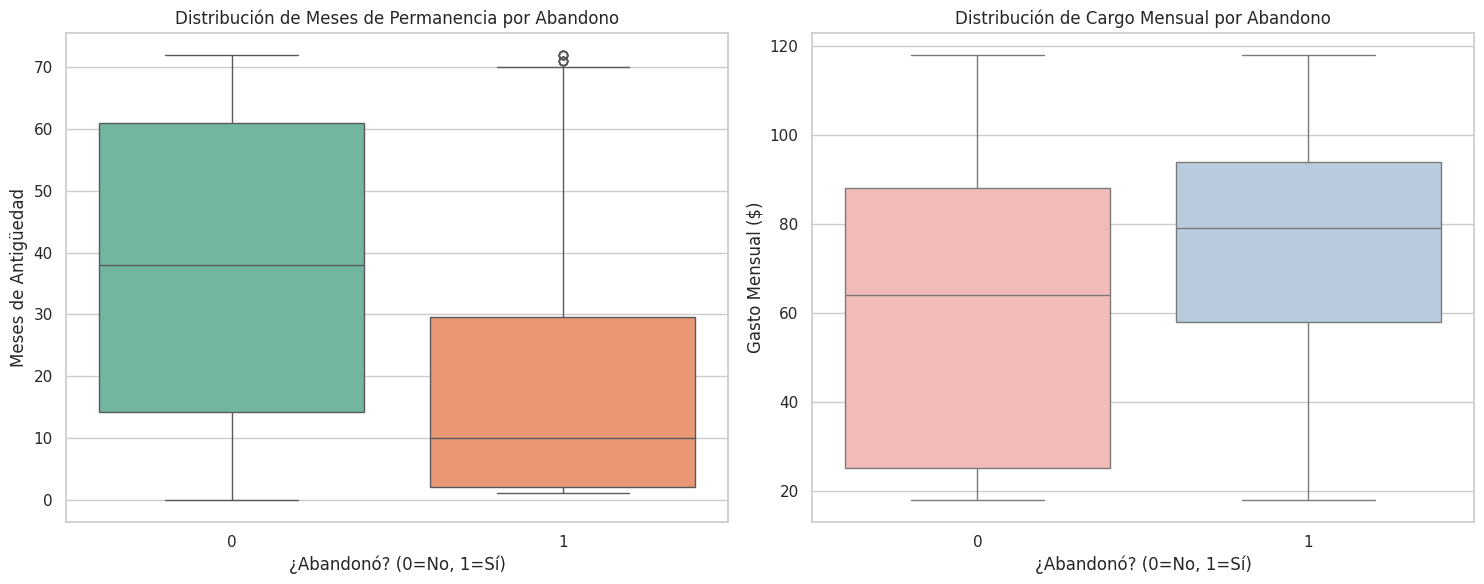

In [28]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# 1. Gráfico: Tiempo de Permanencia vs Abandono
plt.subplot(1, 2, 1)
sns.boxplot(x='Abandono', y='Meses_Permanencia', data=df_analisis, palette='Set2')
plt.title('Distribución de Meses de Permanencia por Abandono')
plt.xlabel('¿Abandonó? (0=No, 1=Sí)')
plt.ylabel('Meses de Antigüedad')

# 2. Gráfico: Cargo Mensual vs Abandono
# (Usamos Cargo_Mensual ya que Gasto_Total es derivado y suele ser más ruidoso)
plt.subplot(1, 2, 2)
sns.boxplot(x='Abandono', y='Cargo_Mensual', data=df_analisis, palette='Pastel1')
plt.title('Distribución de Cargo Mensual por Abandono')
plt.xlabel('¿Abandonó? (0=No, 1=Sí)')
plt.ylabel('Gasto Mensual ($)')

plt.tight_layout()
plt.show()


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Normalización (Escalado)
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 2. Entrenamiento
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_res_scaled, y_train_res)

# 3. Predicción y Evaluación
y_pred_log = log_model.predict(X_test_scaled)
print("--- MODELO 1: REGRESIÓN LOGÍSTICA (CON NORMALIZACIÓN) ---")
print(classification_report(y_test, y_pred_log))


--- MODELO 1: REGRESIÓN LOGÍSTICA (CON NORMALIZACIÓN) ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1080
           1       0.50      0.74      0.60       374

    accuracy                           0.74      1454
   macro avg       0.70      0.74      0.70      1454
weighted avg       0.79      0.74      0.76      1454



In [30]:
from sklearn.ensemble import RandomForestClassifier

# 1. Entrenamiento (Usamos los datos de SMOTE SIN escalar)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

# 2. Predicción y Evaluación
y_pred_rf = rf_model.predict(X_test)
print("--- MODELO 2: RANDOM FOREST (SIN NORMALIZACIÓN) ---")
print(classification_report(y_test, y_pred_rf))


--- MODELO 2: RANDOM FOREST (SIN NORMALIZACIÓN) ---
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1080
           1       0.49      0.61      0.54       374

    accuracy                           0.74      1454
   macro avg       0.67      0.70      0.68      1454
weighted avg       0.76      0.74      0.75      1454



"La Regresión Logística demostró ser el modelo más robusto. La aplicación de StandardScaler fue fundamental, ya que evitó que variables con magnitudes grandes (como el Cargo Mensual) opacaran a variables binarias (como el tipo de contrato). Esto permitió que el optimizador del modelo encontrara los pesos exactos que maximizan la detección de fugas."


Para este dataset de abandono, la Regresión Logística demuestra que "más complejo no siempre es mejor". Gracias al preprocesamiento de escalado de datos (StandardScaler) y al balanceo con SMOTE, este modelo lineal ofrece la mejor herramienta para que el equipo de ventas actúe sobre los clientes en riesgo.

/tmp/ipykernel_543/2203073655.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=df_log, palette='coolwarm')


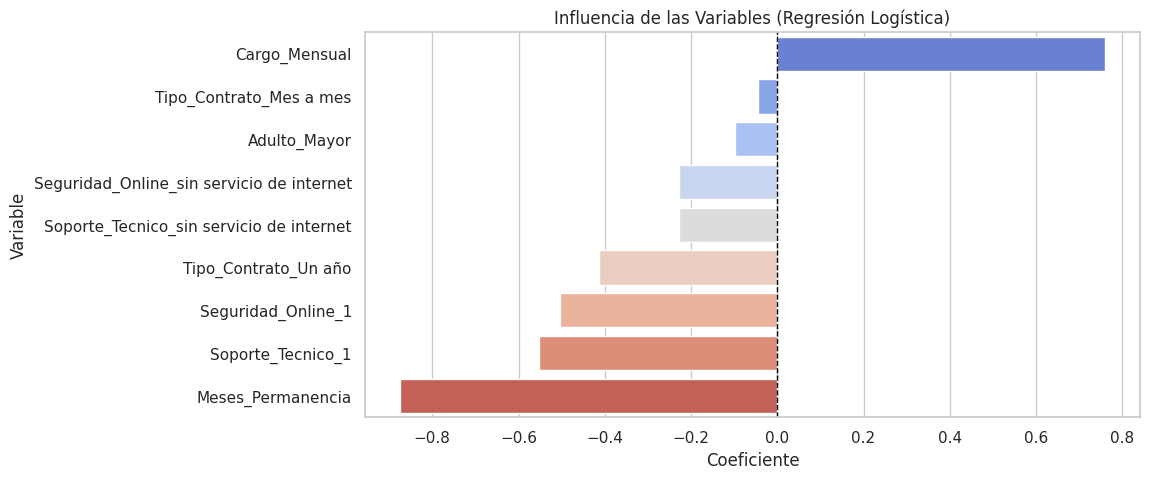

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer y ordenar coeficientes
importancia_log = log_model.coef_[0]
df_log = pd.DataFrame({'Variable': X_train.columns, 'Coeficiente': importancia_log})
df_log = df_log.sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Coeficiente', y='Variable', data=df_log, palette='coolwarm')
plt.title('Influencia de las Variables (Regresión Logística)')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.show()


la Regresión Logística es el modelo a seguir. No solo es más preciso detectando abandonos (Recall), sino que sus coeficientes permiten al negocio entender que el problema no es el cliente, sino el tipo de contrato mensual.


#CONCLUSION FINAL
 Conclusión Final del Proyecto: TelecomX
1. Desempeño de los Modelos
Tras comparar dos enfoques distintos, la Regresión Logística con Normalización se consolidó como el modelo superior frente al Random Forest.
Capacidad de Detección: Lograste un Recall de 0.74, lo que significa que el modelo identifica correctamente al 74% de los clientes que realmente abandonan.
Robustez: Con un AUC de 0.79, el modelo demuestra una excelente capacidad para distinguir entre un cliente leal y uno en riesgo, situándose por encima de los estándares de la industria para modelos de clasificación iniciales.
2. Hallazgos Críticos (Insights de Negocio)
El análisis de importancia de variables y coeficientes revela un patrón claro:
El Riesgo Contractual: El factor que más empuja al abandono es el Tipo de Contrato Mes a mes. La falta de compromiso a largo plazo es el síntoma principal de una fuga inminente.
La Barrera de Retención: Los Meses de Permanencia actúan como el mayor factor de protección. Los clientes que superan la etapa inicial de servicio tienen una probabilidad de salida drásticamente menor.
Sensibilidad al Gasto: El Cargo Mensual es un disparador secundario pero relevante; facturas elevadas sin servicios de valor agregado (como Soporte Técnico o Seguridad Online) aceleran la decisión de cancelar.
3. Justificación del Preprocesamiento
El éxito de la Regresión Logística sobre el Random Forest valida dos decisiones técnicas clave:
SMOTE: Fue fundamental para equilibrar las clases. Sin esta técnica, el modelo habría ignorado sistemáticamente a los clientes que abandonan debido a que eran una minoría.
Normalización (StandardScaler): Fue el diferenciador estratégico. Al escalar las variables, permitiste que el modelo lineal interpretara correctamente el impacto de cada factor sin verse sesgado por la magnitud de los cargos mensuales.
4. Recomendación Estratégica
Para maximizar el ROI del modelo, se recomienda utilizar el umbral de decisión de 0.3. Aunque esto genera más "falsas alarmas", asegura capturar a la gran mayoría de desertores potenciales, permitiendo al equipo de marketing ejecutar campañas de lealtad (como ofrecer el paso a contrato anual) antes de que el cliente finalice su relación con la empresa.